In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [9]:
df.shape

(9568, 5)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [12]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)


In [13]:
type(X_train_scaled)

numpy.ndarray

In [14]:
type(y_train)
y_train.shape

(7654,)

In [15]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [16]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [17]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
        nn.Linear(X_train.shape[1], 6),
        nn.ReLU(),

        nn.Linear(6,6),
        nn.ReLU(),

        nn.Linear(6,1),
    )   

    
    def forward(self,x):
        return self.model(x)

In [18]:
import torch.optim as optim
model=ANN()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [24]:
train_losses=[]
val_losses=[]
best_val_loss= float("inf")
epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss=0.0

    for xb,yb in train_loader:
        optimizer.zero_grad()
        outputs=model(xb)
        loss=criterion(outputs,yb)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()

    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)
    
    model.eval()
    running_val_loss=0.0
    with torch.no_grad():
         for xb,yb in test_loader:
              outputs=model(xb)
              loss=criterion(outputs,yb)
              running_val_loss+=loss
    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch ${epoch+1}/{epochs} ==> train loss = ${epoch_train_loss}& val loss = ${epoch_val_loss}")
    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch $1/100 ==> train loss = $20.979813102881113& val loss = $19.479642868041992
epoch $2/100 ==> train loss = $20.999371818701427& val loss = $19.924766540527344
epoch $3/100 ==> train loss = $20.91729691028595& val loss = $20.35637664794922
epoch $4/100 ==> train loss = $20.87921336491903& val loss = $20.47584342956543
epoch $5/100 ==> train loss = $21.363006714979807& val loss = $19.404367446899414
epoch $6/100 ==> train loss = $21.00985557635625& val loss = $19.16590690612793
epoch $7/100 ==> train loss = $20.940698293844857& val loss = $20.745718002319336
epoch $8/100 ==> train loss = $20.957226099570594& val loss = $19.175437927246094
epoch $9/100 ==> train loss = $21.20451638698578& val loss = $19.145360946655273
epoch $10/100 ==> train loss = $20.979589863618216& val loss = $19.282114028930664
epoch $11/100 ==> train loss = $20.99243749777476& val loss = $19.318635940551758
epoch $12/100 ==> train loss = $21.02425294717153& val loss = $19.60789680480957
epoch $13/100 ==> train

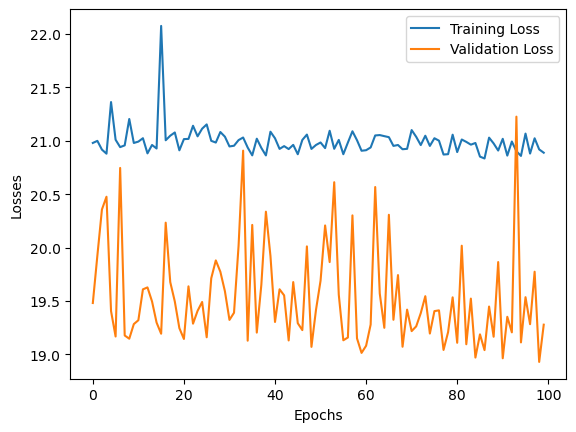

In [25]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":val_losses
})
plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [26]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [28]:
model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)

    train_mse_loss=criterion(train_preds,y_train_tensor)
    test_mse_loss=criterion(test_preds,y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.55154037475586
Testing MSE: 18.933523178100586


In [30]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test,test_preds))

r^2 score = 0.9338322220044757


In [31]:
predicted_df=pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual_values"])

pd.concat([predicted_df,actual_df], axis=1)

,Predicted Values,Actual_values
0,435.388092,433.27
1,436.985840,438.16
2,461.117493,458.42
3,476.123108,480.82
4,435.105316,441.41
...,...,...
1909,451.527588,456.70
1910,431.711670,438.04
1911,467.707611,467.80
1912,431.103119,437.14
